***Car Price Prediction***

In [2]:
#Import the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#sk-learn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


Step 1: Load Dataset

In [4]:
df = pd.read_csv("../dataset/cars.csv")


Step 2: EDA
1. Load Dataset
2. Basic Information
3. Check Shape
4. Check Data Types
5. Missing Values
6. Duplicate Values
7. Statistical Summary
8. Unique Values
9. Target Variable Analysis
10. Numerical Feature Analysis
11. Categorical Feature Analysis
12. Outlier Detection
13. Correlation Check
14. Feature Relationships
15. Data Imbalance
16. Feature Engineering
17. Final Observations

2.Basic Information

In [5]:

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [334]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


Step 3: Check Shape

In [335]:
df.shape

(301, 9)

Step 4: Check Columns

In [336]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

Step 5: Check Data Types


In [337]:
df.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  ...  Seller_Type  Transmission Owner
0       ritz  2014           3.35  ...       Dealer        Manual     0
1        sx4  2013           4.75  ...       Dealer        Manual     0
2       ciaz  2017           7.25  ...       Dealer        Manual     0
3    wagon r  2011           2.85  ...       Dealer        Manual     0
4      swift  2014           4.60  ...       Dealer        Manual     0
..       ...   ...            ...  ...          ...           ...   ...
296     city  2016           9.50  ...       Dealer        Manual     0
297     brio  2015           4.00  ...       Dealer        Manual     0
298     city  2009           3.35  ...       Dealer        Manual     0
299     city  2017          11.50  ...       Dealer        Manual     0
300     brio  2016           5.30  ...       Dealer        Manual     0

[301 rows x 9 columns]>

Step 6: Missing Values

In [338]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [339]:
(df.isnull().sum()/len(df))*100

Car_Name         0.0
Year             0.0
Selling_Price    0.0
Present_Price    0.0
Kms_Driven       0.0
Fuel_Type        0.0
Seller_Type      0.0
Transmission     0.0
Owner            0.0
dtype: float64

Step 7: Duplicate Values

In [340]:
df.duplicated().sum()

df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


Remove duplicates

In [341]:
#Orginal datafram ko duplicate karta hai
    # df.drop_duplicates(inplace=True)


df.drop_duplicates(inplace=True)
#df.drop_duplicates(inplace=True)



Step 8: Statistical Summary

In [342]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.567887,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Step 9: Unique Values

In [343]:
df.nunique()

# single
# df['gender'].unique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

Step 10: Target Variable Analysis

In [344]:
y =df['Present_Price']

print(y)

0       5.59
1       9.54
2       9.85
3       4.15
4       6.87
       ...  
296    11.60
297     5.90
298    11.00
299    12.50
300     5.90
Name: Present_Price, Length: 299, dtype: float64


Check distribution

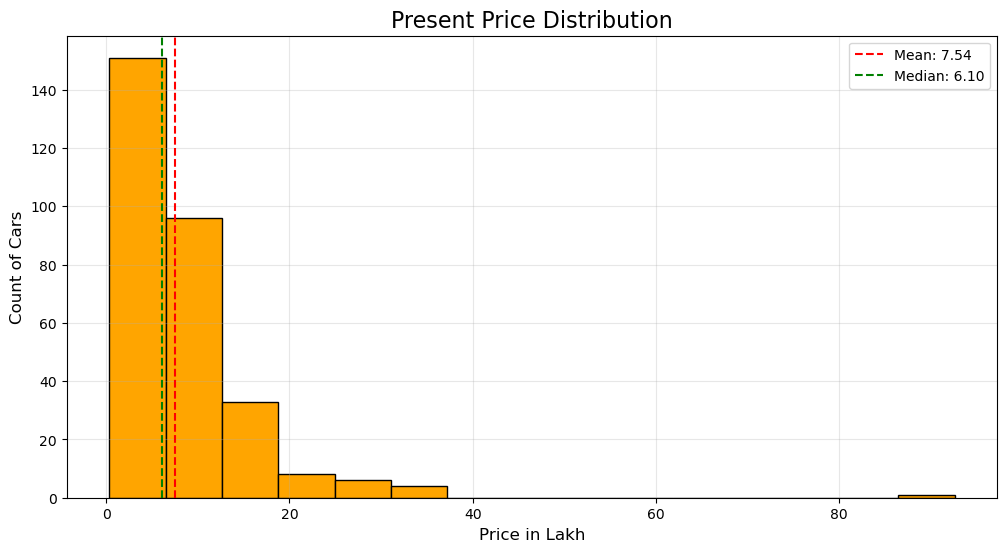

In [345]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.hist(
    df['Present_Price'],
    bins=15,
    color='orange',
    edgecolor='black'
)

plt.axvline(
    df['Present_Price'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {df['Present_Price'].mean():.2f}"
)

plt.axvline(
    df['Present_Price'].median(),
    color='green',
    linestyle='--',
    label=f"Median: {df['Present_Price'].median():.2f}"
)

plt.title("Present Price Distribution", fontsize=16)
plt.xlabel("Price in Lakh", fontsize=12)
plt.ylabel("Count of Cars", fontsize=12)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

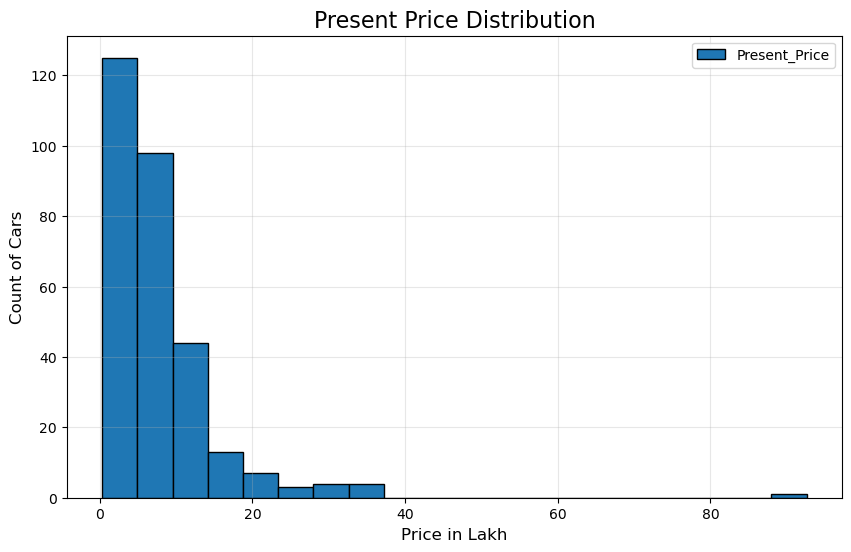

In [346]:
df['Present_Price'].plot(
    kind='hist',
    bins=20,
    figsize=(10,6),
    edgecolor='black'
)


plt.title("Present Price Distribution", fontsize=16)
plt.xlabel("Price in Lakh", fontsize=12)
plt.ylabel("Count of Cars", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

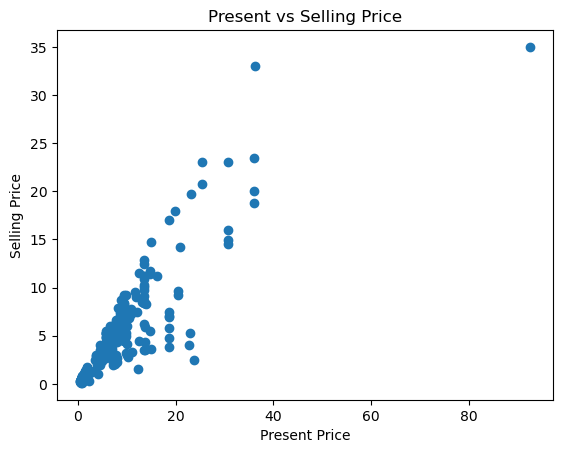

In [347]:
plt.scatter(df['Present_Price'], df['Selling_Price'])
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present vs Selling Price")
plt.show()

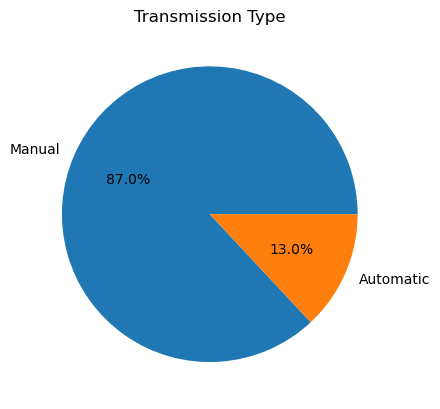

In [348]:
df['Transmission'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Transmission Type")
plt.ylabel("")
plt.show()


Step 11: Numerical Features Analysis


In [349]:
num_cols = df.select_dtypes(include=['int64','float64'])
print(num_cols)

     Year  Selling_Price  Present_Price  Kms_Driven  Owner
0    2014           3.35           5.59       27000      0
1    2013           4.75           9.54       43000      0
2    2017           7.25           9.85        6900      0
3    2011           2.85           4.15        5200      0
4    2014           4.60           6.87       42450      0
..    ...            ...            ...         ...    ...
296  2016           9.50          11.60       33988      0
297  2015           4.00           5.90       60000      0
298  2009           3.35          11.00       87934      0
299  2017          11.50          12.50        9000      0
300  2016           5.30           5.90        5464      0

[299 rows x 5 columns]


Step 12: Categorical Features Analysis


In [350]:
cat_cols = df.select_dtypes(include=['object'])

print(cat_cols)

df['Car_Name'].value_counts()

    Car_Name Fuel_Type Seller_Type Transmission
0       ritz    Petrol      Dealer       Manual
1        sx4    Diesel      Dealer       Manual
2       ciaz    Petrol      Dealer       Manual
3    wagon r    Petrol      Dealer       Manual
4      swift    Diesel      Dealer       Manual
..       ...       ...         ...          ...
296     city    Diesel      Dealer       Manual
297     brio    Petrol      Dealer       Manual
298     city    Petrol      Dealer       Manual
299     city    Diesel      Dealer       Manual
300     brio    Petrol      Dealer       Manual

[299 rows x 4 columns]


Car_Name
city                        26
corolla altis               16
verna                       14
brio                        10
fortuner                    10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64

Step 13: Outlier Detection


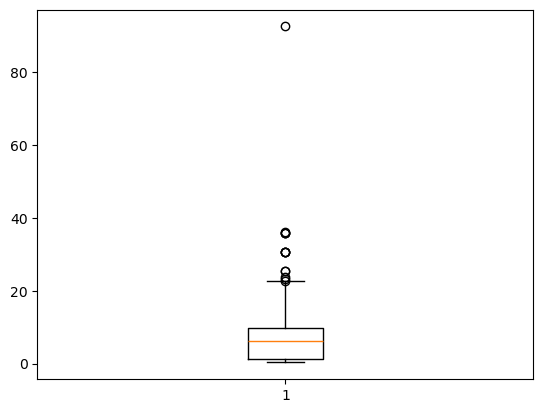

In [351]:

plt.boxplot(df['Present_Price'])
plt.show()

Step 14: Correlation Check

In [352]:
corr = df.corr(numeric_only=True)

print(corr)

                   Year  Selling_Price  Present_Price  Kms_Driven     Owner
Year           1.000000       0.234369      -0.053563   -0.525714 -0.181639
Selling_Price  0.234369       1.000000       0.876378    0.028566 -0.087880
Present_Price -0.053563       0.876378       1.000000    0.205253  0.009947
Kms_Driven    -0.525714       0.028566       0.205253    1.000000  0.089367
Owner         -0.181639      -0.087880       0.009947    0.089367  1.000000


heatmap


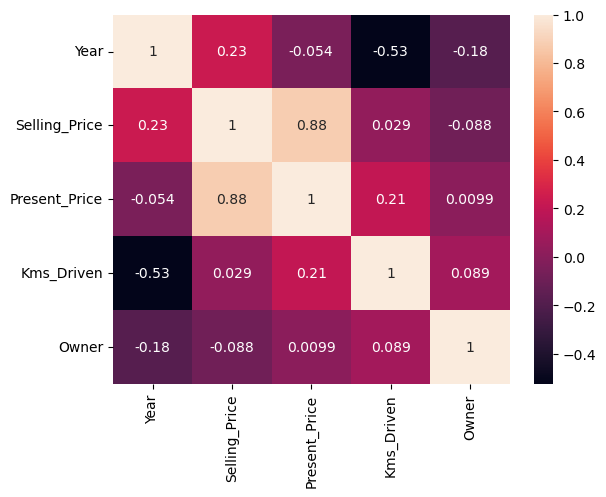

In [353]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True)

plt.show()

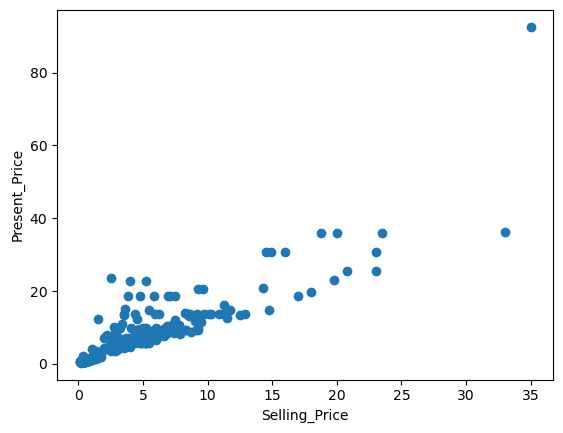

In [354]:
plt.scatter(df['Selling_Price'], df['Present_Price'])

plt.xlabel("Selling_Price")
plt.ylabel("Present_Price")

plt.show()

Step 15: Feature vs Target


In [355]:
Q1 = df['Present_Price'].quantile(0.25)
Q3 = df['Present_Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Present_Price'] < lower) |
    (df['Present_Price'] > upper)
]

print(outliers)

         Car_Name  Year  Selling_Price  ...  Seller_Type  Transmission Owner
50       fortuner  2012          14.90  ...       Dealer     Automatic     0
51       fortuner  2015          23.00  ...       Dealer     Automatic     0
53       fortuner  2013          16.00  ...   Individual     Automatic     0
59       fortuner  2014          19.99  ...       Dealer     Automatic     0
62       fortuner  2014          18.75  ...       Dealer     Automatic     0
63       fortuner  2015          23.50  ...       Dealer     Automatic     0
64       fortuner  2017          33.00  ...       Dealer     Automatic     0
66         innova  2017          19.75  ...       Dealer     Automatic     0
78  corolla altis  2010           5.25  ...       Dealer     Automatic     0
79       fortuner  2012          14.50  ...       Dealer     Automatic     0
82         innova  2017          23.00  ...       Dealer     Automatic     0
85          camry  2006           2.50  ...   Individual     Automatic     3

remove outlier

In [356]:
Q1 = df['Present_Price'].quantile(0.25)
Q3 = df['Present_Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['Present_Price'] >= lower) &
    (df['Present_Price'] <= upper)
]


df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


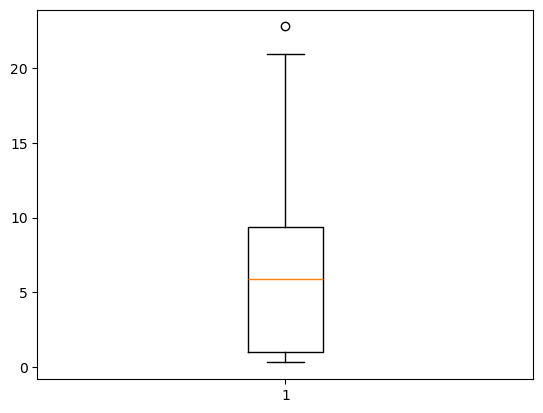

In [357]:
plt.boxplot(df['Present_Price'])
plt.show()

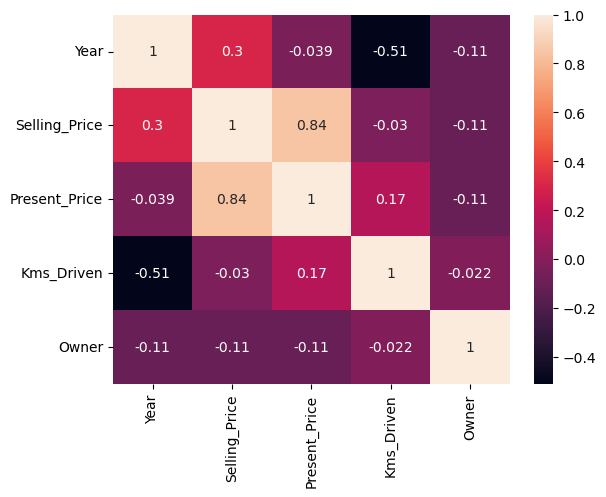

In [358]:
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.show()

Step 16: Check Class Imbalance

In [359]:
df['Present_Price'].value_counts()

Present_Price
9.40     15
13.60    13
5.70      8
1.47      7
4.43      7
         ..
15.04     1
10.21     1
19.77     1
9.29      1
12.50     1
Name: count, Length: 139, dtype: int64

Step 17: Detect Skewness

In [360]:
df.skew(numeric_only=True)

Year            -1.261085
Selling_Price    1.115411
Present_Price    0.781417
Kms_Driven       7.029243
Owner            5.080128
dtype: float64

Step 4: Train Test Split

In [361]:
x = df[['Selling_Price']]
y = df['Present_Price']


X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [362]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [363]:
#Step 6: Prediction
pred = model.predict(X_test)

print(pred)

[10.69080401  9.48703963  1.75760522  4.67198213  7.26957894  6.31923864
  7.90313914  1.56753716  8.21991924  7.26957894  2.58123348 12.64216941
  1.82096124  1.56753716 12.97162072  6.1925266   6.00245854  1.85897485
  1.75760522  8.21991924  2.39116542 19.30722269  3.15143766  8.21991924
  6.95279884  2.77130154 15.50586151  9.36032759 14.06134426  2.45452144
  6.44595068  1.73226281  1.59287957  4.60862611  6.31923864  7.72574228
  6.25588262 10.18395585  1.47883873  6.8260868   4.22848999  4.41855805
  5.05211825  1.90965967  8.72676739  9.42368361  8.02985118  6.31923864
  2.9613696   6.95279884  8.85347943  1.50418114  2.77130154  9.80381973
  2.0110293   5.05211825  8.53669933]


In [364]:
#MAE
mae = mean_absolute_error(y_test, pred)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 1.7357605165111152


In [365]:
mse = mean_squared_error(y_test, pred)
print('Mean Squared Error:', mse)

Mean Squared Error: 9.855269441183893


In [366]:
r2 = r2_score(y_test, pred)
print('R-squared:', r2)

R-squared: 0.6316526847633319


In [367]:
#Check ovetfitting hai
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(train_score)
print(test_score)

0.7325943486187146
0.6316526847633319


In [368]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})


print(result)

     Actual  Predicted
9      8.92  10.690804
265    8.70   9.487040
173    0.51   1.757605
225    4.60   4.671982
89     6.76   7.269579
248    4.60   6.319239
280    5.90   7.903139
186    0.52   1.567537
43     8.06   8.219919
241    7.13   7.269579
47     4.15   2.581233
283   11.80  12.642169
159    0.51   1.820961
184    0.75   1.567537
5      9.83  12.971621
233    5.70   6.192527
246    6.79   6.002459
156    0.52   1.858975
170    0.83   1.757605
34     8.06   8.219919
125    1.75   2.391165
69    20.91  19.307223
77    12.35   3.151438
234    5.70   8.219919
61     7.70   6.952799
109    1.47   2.771302
91    16.09  15.505862
292    8.40   9.360328
289   13.60  14.061344
124    1.75   2.454521
270   10.00   6.445951
174    0.72   1.732263
183    0.47   1.592880
46     4.89   4.608626
94    22.78   6.319239
224    9.40   7.725742
75     6.80   6.255883
98    18.61  10.183956
195    0.32   1.478839
202    5.70   6.826087
31     4.89   4.228490
23     3.46   4.418558
25     4.99